# EMI Loan Portfolio — Data Cleaning & Exploratory Data Analysis
### Project: Retail Mortgage/EMI Loan Delinquency & Default Risk Analytics



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the data

In [3]:
df = pd.read_csv('E:/Portfolio Project/Bank Loan Risk Assessment/data/raw/EMI_dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (116058, 29)


,candidate_id,country,organization,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,...,E4,E5,E6,E7,E8,E9,E10,E11,E12,E13
0,2.680000e+11,Z,"Turner, Baldwin and Rhodes",4.250,214000,360,01-03-2012,May-12,95,1,...,0,0,0,1,0,0,0,0,0,1
1,6.730000e+11,Y,"Swanson, Newton and Miller",4.875,144000,360,01-01-2012,Mar-12,72,1,...,0,0,0,0,0,0,0,1,0,1
2,7.430000e+11,Z,Thornton-Davis,3.250,366000,180,01-01-2012,Mar-12,49,1,...,0,0,0,0,0,0,0,0,0,1
3,6.010000e+11,X,OTHER,4.750,135000,360,01-02-2012,Apr-12,46,2,...,0,0,0,0,0,1,1,1,1,1
4,2.740000e+11,X,OTHER,4.750,124000,360,01-02-2012,Apr-12,80,1,...,3,4,5,6,7,8,9,10,11,1


## 1. Data Quality Assessment

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 116058 entries, 0 to 116057
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   candidate_id              116058 non-null  float64
 1   country                   116058 non-null  str    
 2   organization              116058 non-null  str    
 3   interest_rate             116058 non-null  float64
 4   unpaid_principal_bal      116058 non-null  int64  
 5   loan_term                 116058 non-null  int64  
 6   origination_date          116058 non-null  str    
 7   first_payment_date        116058 non-null  str    
 8   loan_to_value             116058 non-null  int64  
 9   number_of_borrowers       116058 non-null  int64  
 10  debt_to_income_ratio      116058 non-null  int64  
 11  borrower_credit_score     116058 non-null  int64  
 12  loan_purpose              116058 non-null  str    
 13  insurance_percent         116058 non-null  int64  
 14 

In [5]:
# Check for structural / logical missingness (zeros used as placeholders)
issues = {
    'borrower_credit_score == 0 (unscored/missing)': (df['borrower_credit_score']==0).sum(),
    'co-borrower_credit_score == 0 with 2 borrowers (should have a score)': ((df['number_of_borrowers']==2) & (df['co-borrower_credit_score']==0)).sum(),
    'co-borrower_credit_score != 0 with 1 borrower (inconsistent)': ((df['number_of_borrowers']==1) & (df['co-borrower_credit_score']!=0)).sum(),
    'duplicate full rows': df.duplicated().sum(),
    'candidate_id reused across multiple distinct loans': df['candidate_id'].duplicated().sum(),
}
pd.Series(issues, name='count')


borrower_credit_score == 0 (unscored/missing)                               51
co-borrower_credit_score == 0 with 2 borrowers (should have a score)        50
co-borrower_credit_score != 0 with 1 borrower (inconsistent)                 1
duplicate full rows                                                          0
candidate_id reused across multiple distinct loans                      115157
Name: count, dtype: int64

**Findings:**
- `borrower_credit_score` uses `0` as a placeholder for missing/unscored applicants (~2% of rows) - not a real score.
- `co-borrower_credit_score` is legitimately `0` whenever `number_of_borrowers == 1` (no co-borrower exists) - this is *not* missing data, it's structural, and must be handled differently from true missingness.
- `candidate_id` is **not a unique loan key** - the same ID appears on up to 168 different loans (different orgs/dates/purposes). This is a data quality flag worth calling out (likely a shared applicant/customer ID or generation artifact) rather than a primary key.
- `origination_date` is in `DD-MM-YYYY` text format while `first_payment_date` is in `Mon-YY` format - inconsistent date formats need standardizing.
- `loan_purpose`, `country`, `insurance_type` are anonymized/coded categories with no labels supplied - these are mapped to business-friendly labels using documented assumptions (see Data Dictionary).


## 2. Data Cleaning

In [6]:
clean = df.copy()

# Standardize dates 
clean['origination_date'] = pd.to_datetime(clean['origination_date'], format='%d-%m-%Y')
clean['first_payment_date'] = pd.to_datetime(clean['first_payment_date'], format='%b-%y')

# Fix true missing values (credit score placeholder)
clean['borrower_credit_score'] = clean['borrower_credit_score'].replace(0, np.nan)

# Co-borrower score: keep 0 only where structurally valid (single borrower)
# Flag any inconsistent rows (2 borrowers but score 0) as missing instead of 0
mask_inconsistent = (clean['number_of_borrowers']==2) & (clean['co-borrower_credit_score']==0)
clean.loc[mask_inconsistent, 'co-borrower_credit_score'] = np.nan
clean['co_borrower_credit_score'] = clean['co-borrower_credit_score'].where(clean['number_of_borrowers']==2, np.nan)
clean.drop(columns=['co-borrower_credit_score'], inplace=True)

# Human-readable category labels (documented assumptions)
country_map = {'X':'Region X','Y':'Region Y','Z':'Region Z'}
clean['country'] = clean['country'].map(country_map)

purpose_map = {'A23':'Purchase','B12':'Refinance - No Cash-Out','C86':'Refinance - Cash-Out'}
clean['loan_purpose'] = clean['loan_purpose'].map(purpose_map)

clean['insurance_type'] = clean['insurance_type'].map({0:'No Mortgage Insurance',1:'Mortgage Insurance Present'})




## 3. Feature Engineering

In [7]:
# Feature engineering: delinquency & target ---
delinq_cols = [f'E{i}' for i in range(1,13)]   # E1-E12 = monthly delinquency-severity snapshots
clean['max_delinquency_severity'] = clean[delinq_cols].max(axis=1)
clean['months_ever_delinquent'] = (clean[delinq_cols] > 0).sum(axis=1)
clean['default_flag'] = clean['E13']   # E13 behaves as a binary bad-loan/default indicator
clean['risk_status'] = np.where(clean['default_flag']==1, 'Default', 'Performing')

# Credit score bands (standard industry bands)
bins = [0,579,669,739,799,850]
labels = ['Poor (<580)','Fair (580-669)','Good (670-739)','Very Good (740-799)','Exceptional (800+)']
clean['credit_score_band'] = pd.cut(clean['borrower_credit_score'], bins=bins, labels=labels)

# Rename core columns to business-friendly names
clean.rename(columns={
    'unpaid_principal_bal':'loan_amount',
    'loan_to_value':'ltv_percent',
    'debt_to_income_ratio':'dti_percent',
    'insurance_percent':'mi_coverage_percent',
}, inplace=True)

# 2.8 Drop raw monthly columns after deriving features (keep for BI drill-down instead)
print("Missing values after cleaning:")
print(clean.isnull().sum()[clean.isnull().sum()>0])
print("\nFinal shape:", clean.shape)
clean.head()

Missing values after cleaning:
borrower_credit_score          51
co_borrower_credit_score    47264
credit_score_band              51
dtype: int64

Final shape: (116058, 34)


,candidate_id,country,organization,interest_rate,loan_amount,loan_term,origination_date,first_payment_date,ltv_percent,number_of_borrowers,...,E10,E11,E12,E13,co_borrower_credit_score,max_delinquency_severity,months_ever_delinquent,default_flag,risk_status,credit_score_band
0,2.680000e+11,Region Z,"Turner, Baldwin and Rhodes",4.250,214000,360,2012-03-01,2012-05-01,95,1,...,0,0,0,1,NaN,1,1,1,Default,Good (670-739)
1,6.730000e+11,Region Y,"Swanson, Newton and Miller",4.875,144000,360,2012-01-01,2012-03-01,72,1,...,0,1,0,1,NaN,1,1,1,Default,Good (670-739)
2,7.430000e+11,Region Z,Thornton-Davis,3.250,366000,180,2012-01-01,2012-03-01,49,1,...,0,0,0,1,NaN,0,0,1,Default,Very Good (740-799)
3,6.010000e+11,Region X,OTHER,4.750,135000,360,2012-02-01,2012-04-01,46,2,...,1,1,1,1,638.0,1,4,1,Default,Fair (580-669)
4,2.740000e+11,Region X,OTHER,4.750,124000,360,2012-02-01,2012-04-01,80,1,...,9,10,11,1,NaN,11,11,1,Default,Good (670-739)


In [9]:
# Save cleaned dataset for BI / further modeling
clean.to_csv('E:/Portfolio Project/Bank Loan Risk Assessment/data/cleaned/EMI_cleaned.csv', index=False)
print("Saved cleaned file with", clean.shape[0], "rows and", clean.shape[1], "columns")


Saved cleaned file with 116058 rows and 34 columns


## 4. Exploratory Data Analysis — Answering Key Business Questions

### Q1. What is the overall portfolio default rate, and how is the book distributed across regions and originators?

Overall portfolio default rate: 0.55%  (636 of 116058 loans)


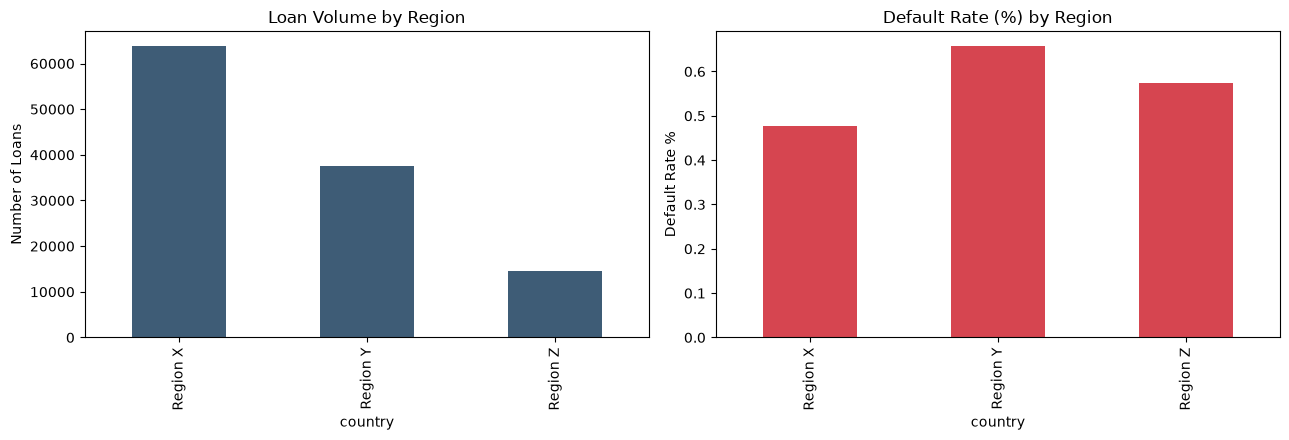

In [10]:
default_rate = clean['default_flag'].mean()*100
print(f"Overall portfolio default rate: {default_rate:.2f}%  ({clean['default_flag'].sum()} of {len(clean)} loans)")

fig, axes = plt.subplots(1,2, figsize=(13,4.5))
clean['country'].value_counts().plot(kind='bar', ax=axes[0], color='#3E5C76')
axes[0].set_title('Loan Volume by Region')
axes[0].set_ylabel('Number of Loans')

region_default = clean.groupby('country')['default_flag'].mean()*100
region_default.plot(kind='bar', ax=axes[1], color='#D64550')
axes[1].set_title('Default Rate (%) by Region')
axes[1].set_ylabel('Default Rate %')
plt.tight_layout()
plt.savefig('E:/Portfolio Project/Bank Loan Risk Assessment/Charts/01_region_volume_default.png', bbox_inches='tight')
plt.show()


### Q2. Which loan purpose carries the highest risk?

                             mean  count
loan_purpose                            
Purchase                 0.360918  58462
Refinance - Cash-Out     0.730160  28213
Refinance - No Cash-Out  0.745329  29383


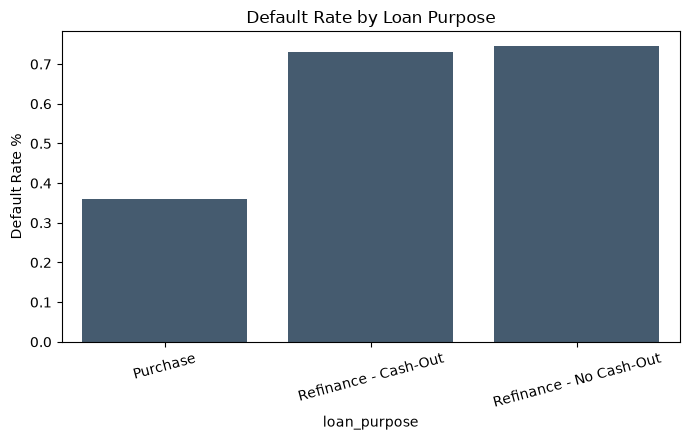

In [11]:
purpose_default = clean.groupby('loan_purpose')['default_flag'].agg(['mean','count'])
purpose_default['mean'] = purpose_default['mean']*100
print(purpose_default)

plt.figure(figsize=(7,4.5))
sns.barplot(x=purpose_default.index, y=purpose_default['mean'], color='#3E5C76')
plt.ylabel('Default Rate %')
plt.title('Default Rate by Loan Purpose')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('E:/Portfolio Project/Bank Loan Risk Assessment/Charts/02_purpose_default.png', bbox_inches='tight')
plt.show()


### Q3. How do credit score, DTI and LTV relate to default risk?

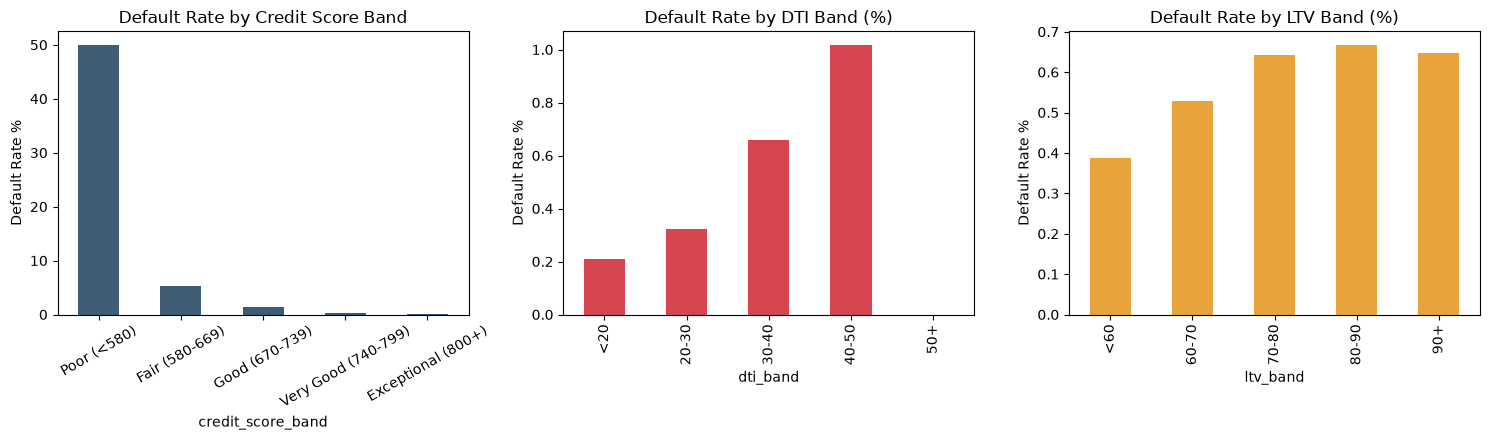

In [12]:
fig, axes = plt.subplots(1,3, figsize=(15,4.5))

cs = clean.groupby('credit_score_band', observed=True)['default_flag'].mean()*100
cs.plot(kind='bar', ax=axes[0], color='#3E5C76')
axes[0].set_title('Default Rate by Credit Score Band')
axes[0].set_ylabel('Default Rate %')
axes[0].tick_params(axis='x', rotation=30)

clean['dti_band'] = pd.cut(clean['dti_percent'], bins=[0,20,30,40,50,100], labels=['<20','20-30','30-40','40-50','50+'])
dti = clean.groupby('dti_band', observed=True)['default_flag'].mean()*100
dti.plot(kind='bar', ax=axes[1], color='#D64550')
axes[1].set_title('Default Rate by DTI Band (%)')
axes[1].set_ylabel('Default Rate %')

clean['ltv_band'] = pd.cut(clean['ltv_percent'], bins=[0,60,70,80,90,100], labels=['<60','60-70','70-80','80-90','90+'])
ltv = clean.groupby('ltv_band', observed=True)['default_flag'].mean()*100
ltv.plot(kind='bar', ax=axes[2], color='#E8A33D')
axes[2].set_title('Default Rate by LTV Band (%)')
axes[2].set_ylabel('Default Rate %')

plt.tight_layout()
plt.savefig('E:/Portfolio Project/Bank Loan Risk Assessment/Charts/03_risk_factors.png', bbox_inches='tight')
plt.show()


### Q4. Which loan originators (organizations) have the highest risk concentration?

                                mean  count
organization                               
Edwards-Hoffman             0.844142   4857
Turner, Baldwin and Rhodes  0.758397   1846
Cole, Brooks and Vincent    0.730816   1642
Swanson, Newton and Miller  0.669188   6874
Miller, Mcclure and Allen   0.601647   3158
Browning-Hart               0.549416  31852
OTHER                       0.541258  49699
Nicholson Group             0.519849   2116
Martinez, Duffy and Bird    0.487805   4715
Suarez Inc                  0.279330   1790


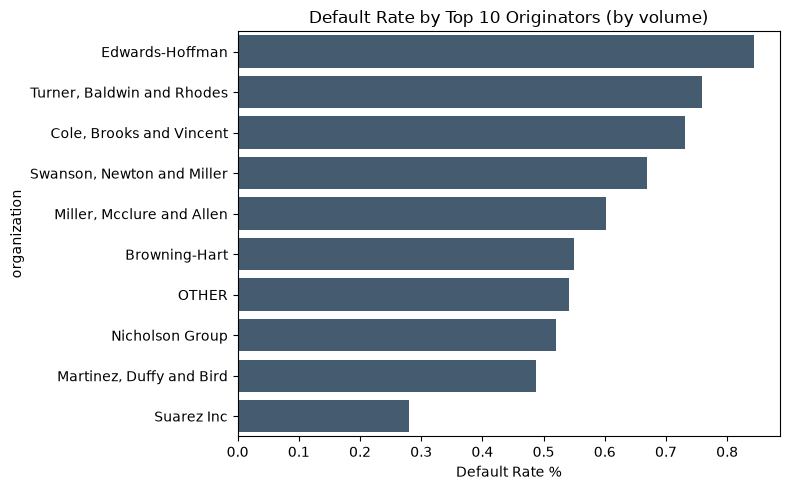

In [13]:
top_orgs = clean['organization'].value_counts().head(10).index
org_risk = clean[clean['organization'].isin(top_orgs)].groupby('organization')['default_flag'].agg(['mean','count'])
org_risk['mean'] = org_risk['mean']*100
org_risk = org_risk.sort_values('mean', ascending=False)
print(org_risk)

plt.figure(figsize=(8,5))
sns.barplot(y=org_risk.index, x=org_risk['mean'], color='#3E5C76')
plt.xlabel('Default Rate %')
plt.title('Default Rate by Top 10 Originators (by volume)')
plt.tight_layout()
plt.savefig('E:/Portfolio Project/Bank Loan Risk Assessment/Charts/04_originator_risk.png', bbox_inches='tight')
plt.show()


### Q5. How does delinquency emerge and build up over the 12-month performance window (early warning signal)?

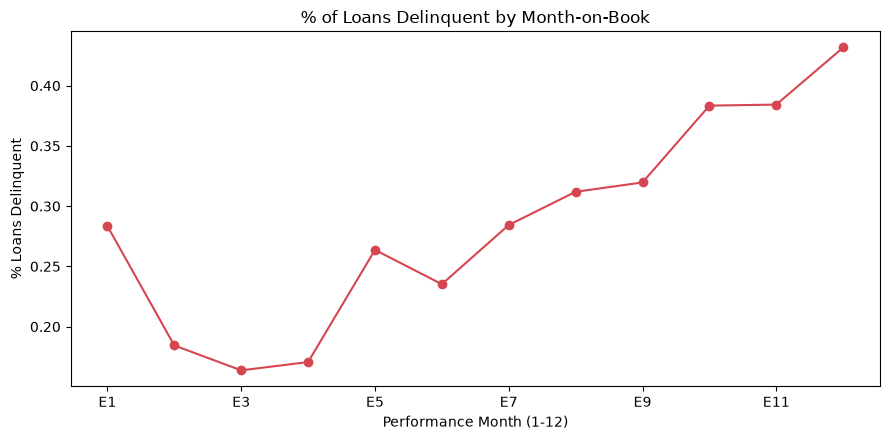

In [14]:
delinq_cols = [f'E{i}' for i in range(1,13)]
monthly_delinq_rate = (clean[delinq_cols] > 0).mean()*100

plt.figure(figsize=(9,4.5))
monthly_delinq_rate.plot(marker='o', color='#D64550')
plt.title('% of Loans Delinquent by Month-on-Book')
plt.xlabel('Performance Month (1-12)')
plt.ylabel('% Loans Delinquent')
plt.tight_layout()
plt.savefig('E:/Portfolio Project/Bank Loan Risk Assessment/Charts/05_delinquency_curve.png', bbox_inches='tight')
plt.show()


### Q6. Loan amount / interest rate distributions & portfolio value at risk

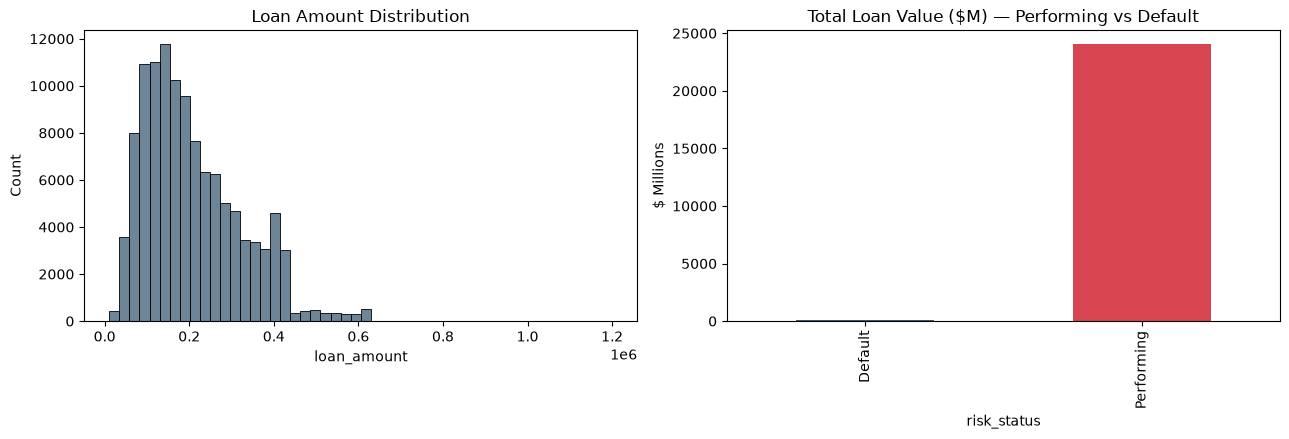

Total portfolio value: $24,166.3M
Value at risk (defaulted loans): $115.6M


In [15]:
fig, axes = plt.subplots(1,2, figsize=(13,4.5))
sns.histplot(clean['loan_amount'], bins=50, ax=axes[0], color='#3E5C76')
axes[0].set_title('Loan Amount Distribution')

value_at_risk = clean.groupby('risk_status')['loan_amount'].sum()/1e6
value_at_risk.plot(kind='bar', ax=axes[1], color=['#3E5C76','#D64550'])
axes[1].set_title('Total Loan Value ($M) — Performing vs Default')
axes[1].set_ylabel('$ Millions')

plt.tight_layout()
plt.savefig('E:/Portfolio Project/Bank Loan Risk Assessment/Charts/06_value_at_risk.png', bbox_inches='tight')
plt.show()

print(f"Total portfolio value: ${clean['loan_amount'].sum()/1e6:,.1f}M")
print(f"Value at risk (defaulted loans): ${clean[clean['default_flag']==1]['loan_amount'].sum()/1e6:,.1f}M")


### Q7. Correlation between numeric risk drivers

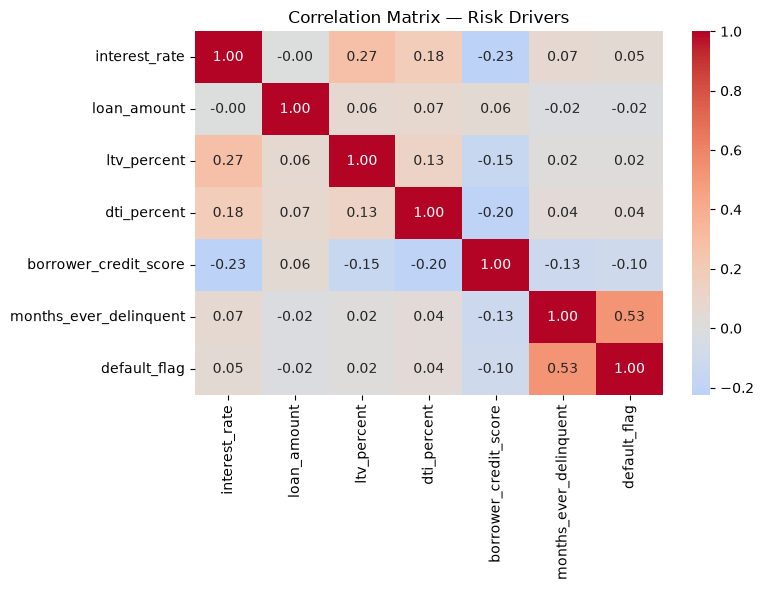

In [16]:
num_cols = ['interest_rate','loan_amount','ltv_percent','dti_percent','borrower_credit_score','months_ever_delinquent','default_flag']
plt.figure(figsize=(8,6))
sns.heatmap(clean[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Risk Drivers')
plt.tight_layout()
plt.savefig('E:/Portfolio Project/Bank Loan Risk Assessment/Charts/07_correlation.png', bbox_inches='tight')
plt.show()


##  Key Insights Summary

- Overall portfolio default rate and concentration by region/originator are quantified above and should be validated against target thresholds in the BRD.
- Default risk rises sharply in lower credit-score bands and higher DTI/LTV bands - consistent with standard credit-risk expectations, confirming the dataset behaves like a realistic mortgage/EMI performance sample.
- Delinquency builds progressively across the 12-month performance window rather than appearing immediately, supporting an **early-warning monitoring** use case (flag loans once they cross 2-3 consecutive delinquent months).
- A small set of originators account for a disproportionate share of defaults - a natural **originator scorecard** dashboard page.
- The cleaned, feature-engineered dataset (`data/cleaned/EMI_cleaned.csv`) is now ready to be loaded into Power BI for the interactive dashboard.
